In [54]:
from imd_features.interpolate import predict_quarter
import polars as pl
import pathlib
from project_paths import paths, project_root


input_dir = project_root / "data" / "input"

anchor_files = [input_dir/"combined_data_2019-09-01.parquet", input_dir/"combined_data_2025-10-01.parquet"]
quarters = [file for file in input_dir.glob("combined_indicators_*.parquet") if file not in anchor_files]

print([str(f) for f in anchor_files])
print([str(f) for f in quarters])


quarter_scores = [predict_quarter(path, str(path.stem).removeprefix("combined_indicators_")) for path in quarters]

scores_df = pl.concat(quarter_scores, how="vertical")

ic| quarterly_parquet_path: WindowsPath('C:/Users/Daniel/projects/imd_feature_engineering/data/input/combined_indicators_2020-01-01.parquet')
    snapshot_date: '2020-01-01'
    _FITTED_MODELS is None: False


ic| df_input.shape: (268, 387)
    df_input.columns: ['lsoa_code',
                       'robbery',
                       'drugs',
                       'possession-of-weapons',
                       'vehicle-crime',
                       'other-theft',
                       'anti-social-behaviour',


['C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_data_2019-09-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_data_2025-10-01.parquet']
['C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-01-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-04-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-07-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2020-10-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-01-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-04-01.parquet', 'C:\\Users\\Daniel\\projects\\imd_feature_engineering\\data\\input\\combined_indicators_2021-07-01.parquet', 'C:\\Users\\Daniel\\projects\

                       'public-order',
                       'bicycle-theft',
                       'criminal-damage-arson',
                       'other-crime',
                       'theft-from-the-person',
                       'violent-crime',
                       'shoplifting',
                       'burglary',
                       'Further action is not in the public interest',
                       'Court result unavailable',
                       'Local resolution',
                       'Offender given a caution',
                       'Unable to prosecute suspect',
                       'Under investigation',
                       'Awaiting court outcome',
                       'Suspect charged as part of another case',
                       'Further investigation is not in the public interest',
                       'Formal action is not in the public interest',
                       'Status update unavailable',
                       'Offender given a dr

In [55]:
# scores_df.plot.line(x="snapshot_date", y="score", colour="lsoa_code")

scores_df


lsoa_code,snapshot_date,predicted_score
str,str,f64
"""E01014485""","""2020-01-01""",28.863593
"""E01014486""","""2020-01-01""",38.395936
"""E01014487""","""2020-01-01""",20.070865
"""E01014488""","""2020-01-01""",24.722108
"""E01014489""","""2020-01-01""",33.00176
…,…,…
"""E01033906""","""2025-07-01""",9.458219
"""E01033907""","""2025-07-01""",25.174911
"""E01033908""","""2025-07-01""",17.39195


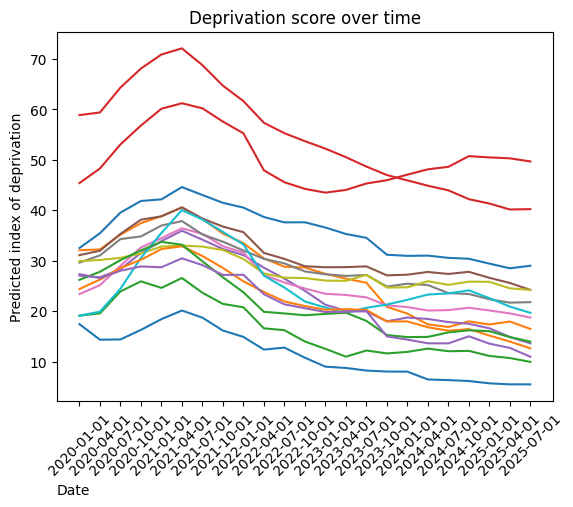

In [56]:
import matplotlib.pyplot as plt
from random import choices

ax = plt.axes()

lsoa_codes = scores_df.get_column("lsoa_code").unique().to_list()

to_plot = choices(lsoa_codes, k=15)

for code in to_plot:

    df = scores_df.filter(pl.col("lsoa_code").eq(code))

    ax.plot(
        df.get_column("snapshot_date"),
        df.get_column("predicted_score"),
    )

ax.set_title("Deprivation score over time")

ax.set_ylabel("Predicted index of deprivation")
ax.set_xlabel("Date", loc="left")
ax.tick_params(axis="x", labelrotation=45)

plt.show()


In [57]:
scores_df = scores_df.with_columns(
    pl.col("predicted_score").rank(descending=True).over(partition_by="snapshot_date").alias("rank"),
).with_columns(
    (((pl.col("rank") - 1) * 10 // pl.col("rank").len().over(partition_by="snapshot_date")) + 1)
        .cast(pl.Int32)
        .alias("decile")
)


scores_df

lsoa_code,snapshot_date,predicted_score,rank,decile
str,str,f64,f64,i32
"""E01014485""","""2020-01-01""",28.863593,114.0,5
"""E01014486""","""2020-01-01""",38.395936,48.0,2
"""E01014487""","""2020-01-01""",20.070865,199.0,8
"""E01014488""","""2020-01-01""",24.722108,167.0,7
"""E01014489""","""2020-01-01""",33.00176,75.0,3
…,…,…,…,…
"""E01033906""","""2025-07-01""",9.458219,215.0,8
"""E01033907""","""2025-07-01""",25.174911,91.0,4
"""E01033908""","""2025-07-01""",17.39195,151.0,6


In [58]:
with pl.Config(tbl_rows=10000):
    print(scores_df)

shape: (6_164, 5)
┌───────────┬───────────────┬─────────────────┬───────┬────────┐
│ lsoa_code ┆ snapshot_date ┆ predicted_score ┆ rank  ┆ decile │
│ ---       ┆ ---           ┆ ---             ┆ ---   ┆ ---    │
│ str       ┆ str           ┆ f64             ┆ f64   ┆ i32    │
╞═══════════╪═══════════════╪═════════════════╪═══════╪════════╡
│ E01014485 ┆ 2020-01-01    ┆ 28.863593       ┆ 114.0 ┆ 5      │
│ E01014486 ┆ 2020-01-01    ┆ 38.395936       ┆ 48.0  ┆ 2      │
│ E01014487 ┆ 2020-01-01    ┆ 20.070865       ┆ 199.0 ┆ 8      │
│ E01014488 ┆ 2020-01-01    ┆ 24.722108       ┆ 167.0 ┆ 7      │
│ E01014489 ┆ 2020-01-01    ┆ 33.00176        ┆ 75.0  ┆ 3      │
│ E01014491 ┆ 2020-01-01    ┆ 22.411338       ┆ 188.0 ┆ 7      │
│ E01014492 ┆ 2020-01-01    ┆ 34.252897       ┆ 68.0  ┆ 3      │
│ E01014493 ┆ 2020-01-01    ┆ 38.160036       ┆ 50.0  ┆ 2      │
│ E01014494 ┆ 2020-01-01    ┆ 24.799137       ┆ 163.0 ┆ 7      │
│ E01014495 ┆ 2020-01-01    ┆ 28.884555       ┆ 112.0 ┆ 5      │
│ E0101

Below are outputs used as sense checks to make sure the rank and decile run in the expected order

In [59]:
scores_df.filter(pl.col("lsoa_code")=="E01033906")

lsoa_code,snapshot_date,predicted_score,rank,decile
str,str,f64,f64,i32
"""E01033906""","""2020-01-01""",25.85416,151.0,6
"""E01033906""","""2020-04-01""",25.664285,159.0,6
"""E01033906""","""2020-07-01""",25.6973,182.0,7
"""E01033906""","""2020-10-01""",26.602388,191.0,8
"""E01033906""","""2021-01-01""",25.127165,203.0,8
…,…,…,…,…
"""E01033906""","""2024-07-01""",8.781259,229.0,9
"""E01033906""","""2024-10-01""",8.769819,231.0,9
"""E01033906""","""2025-01-01""",9.346039,224.0,9


Code below is for exporting the final results so that they can be used in the dashboard

In [60]:
score_recs = scores_df.to_dicts()

score_recs

[{'lsoa_code': 'E01014485',
  'snapshot_date': '2020-01-01',
  'predicted_score': 28.863592905476267,
  'rank': 114.0,
  'decile': 5},
 {'lsoa_code': 'E01014486',
  'snapshot_date': '2020-01-01',
  'predicted_score': 38.39593620671219,
  'rank': 48.0,
  'decile': 2},
 {'lsoa_code': 'E01014487',
  'snapshot_date': '2020-01-01',
  'predicted_score': 20.07086528057233,
  'rank': 199.0,
  'decile': 8},
 {'lsoa_code': 'E01014488',
  'snapshot_date': '2020-01-01',
  'predicted_score': 24.7221084733172,
  'rank': 167.0,
  'decile': 7},
 {'lsoa_code': 'E01014489',
  'snapshot_date': '2020-01-01',
  'predicted_score': 33.001759811636084,
  'rank': 75.0,
  'decile': 3},
 {'lsoa_code': 'E01014491',
  'snapshot_date': '2020-01-01',
  'predicted_score': 22.411337757090006,
  'rank': 188.0,
  'decile': 7},
 {'lsoa_code': 'E01014492',
  'snapshot_date': '2020-01-01',
  'predicted_score': 34.252896635508435,
  'rank': 68.0,
  'decile': 3},
 {'lsoa_code': 'E01014493',
  'snapshot_date': '2020-01-01',
 

In [61]:
example = scores_df.filter(pl.col("lsoa_code")=="E01033906")

# scores_records = {
#     "lsoa_code": example.get_column("lsoa_code").to_list()[0],
#     "scores": {
#         "date": ... ,
#         "rank":

#     }
# }

row = example # .filter(pl.col("snapshot_date")=="2024-01-01")

scores_records = row.to_dicts()

scores_records

[{'lsoa_code': 'E01033906',
  'snapshot_date': '2020-01-01',
  'predicted_score': 25.85416047705176,
  'rank': 151.0,
  'decile': 6},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2020-04-01',
  'predicted_score': 25.664285372275785,
  'rank': 159.0,
  'decile': 6},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2020-07-01',
  'predicted_score': 25.697299678260155,
  'rank': 182.0,
  'decile': 7},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2020-10-01',
  'predicted_score': 26.60238839399817,
  'rank': 191.0,
  'decile': 8},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2021-01-01',
  'predicted_score': 25.12716543662644,
  'rank': 203.0,
  'decile': 8},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2021-04-01',
  'predicted_score': 27.304786668995273,
  'rank': 195.0,
  'decile': 8},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2021-07-01',
  'predicted_score': 29.306289567426745,
  'rank': 169.0,
  'decile': 7},
 {'lsoa_code': 'E01033906',
  'snapshot_date': '2021-10-01

In [62]:
result = (
    scores_df.sort("snapshot_date")
    .group_by("lsoa_code")
    .agg([
        pl.struct("snapshot_date", "rank", "decile", "predicted_score").alias("points")
    ])
).to_dicts()

# result

import json 

output_path = project_root / "data" / "output" / "interpolated_scores.json"

output_path.write_text(json.dumps(result))

621692